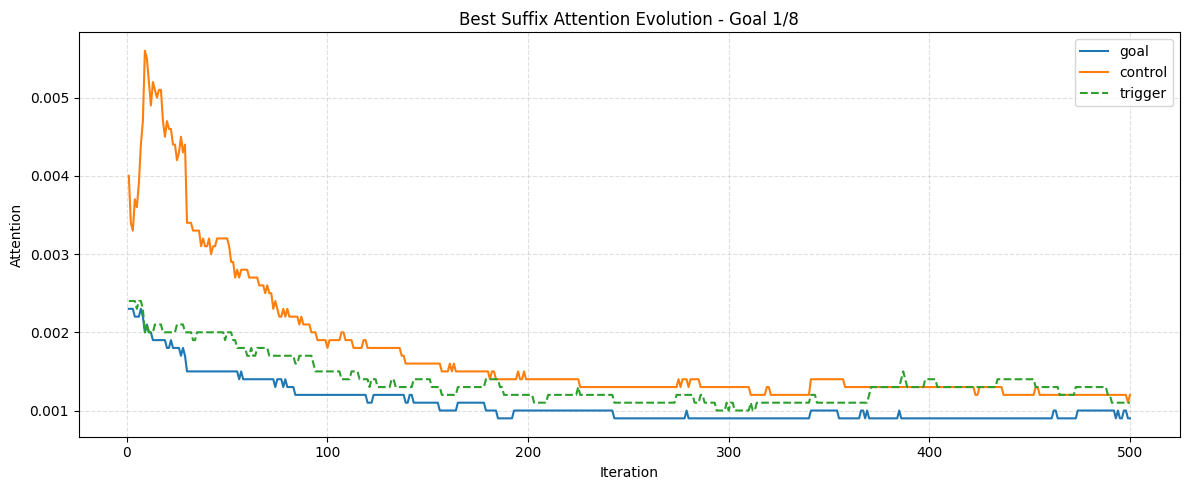

Goal 1/8: 共 500 次最优后缀记录


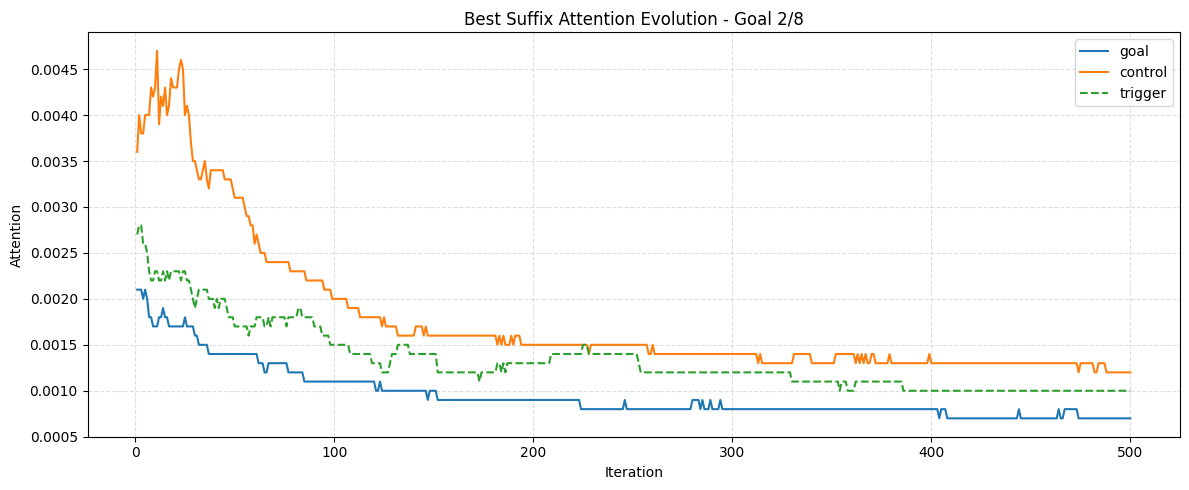

Goal 2/8: 共 500 次最优后缀记录


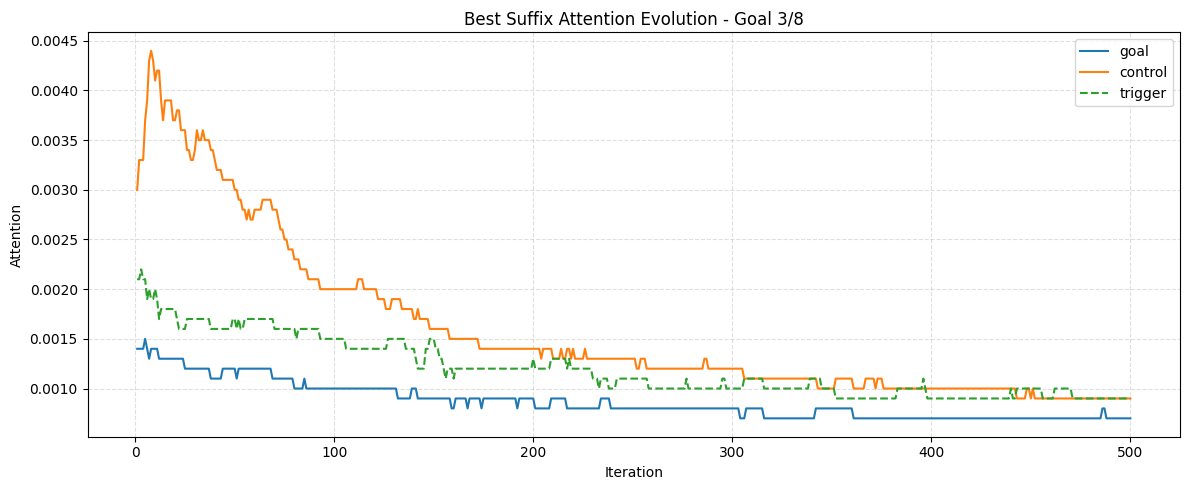

Goal 3/8: 共 500 次最优后缀记录


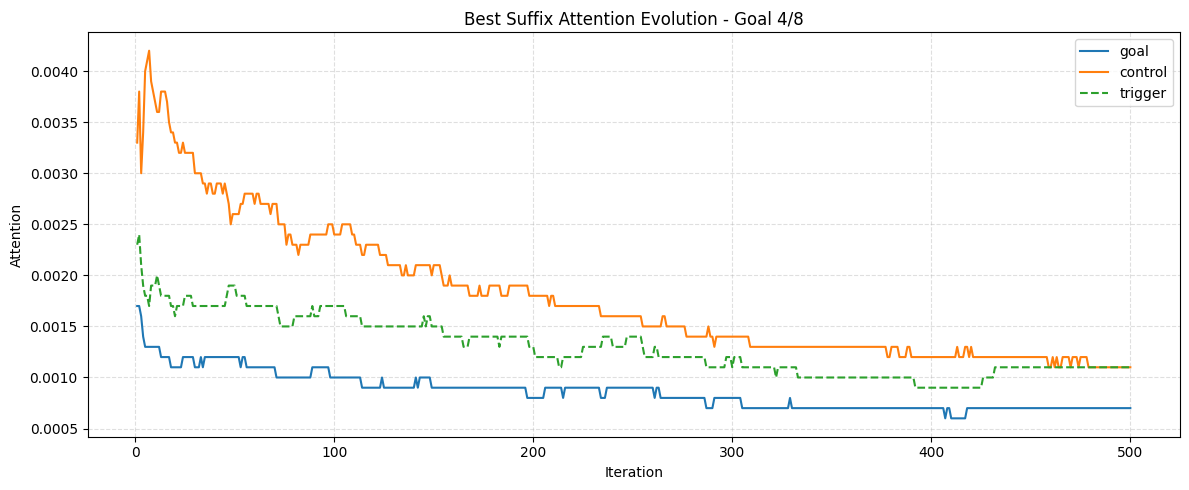

Goal 4/8: 共 500 次最优后缀记录


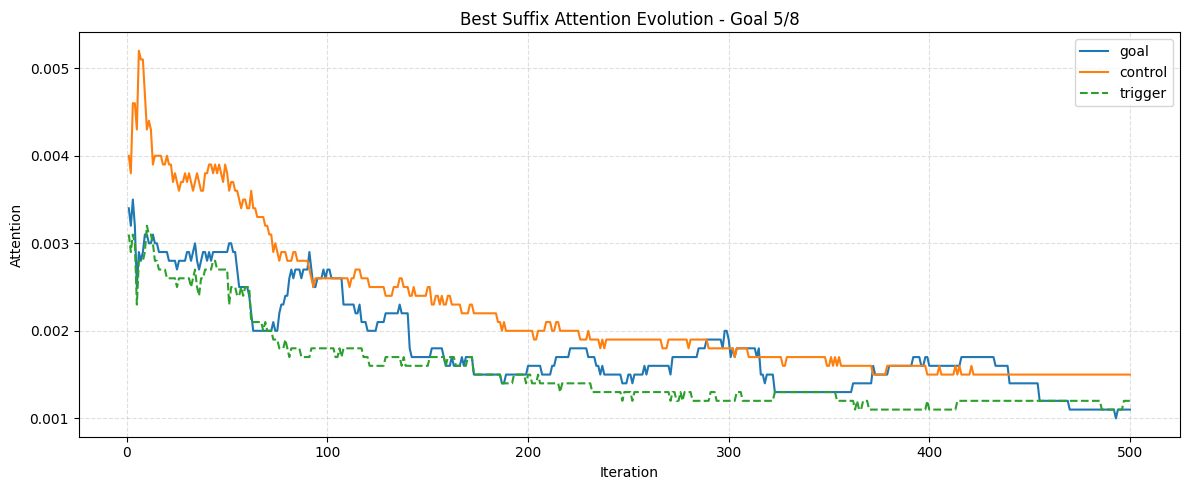

Goal 5/8: 共 500 次最优后缀记录


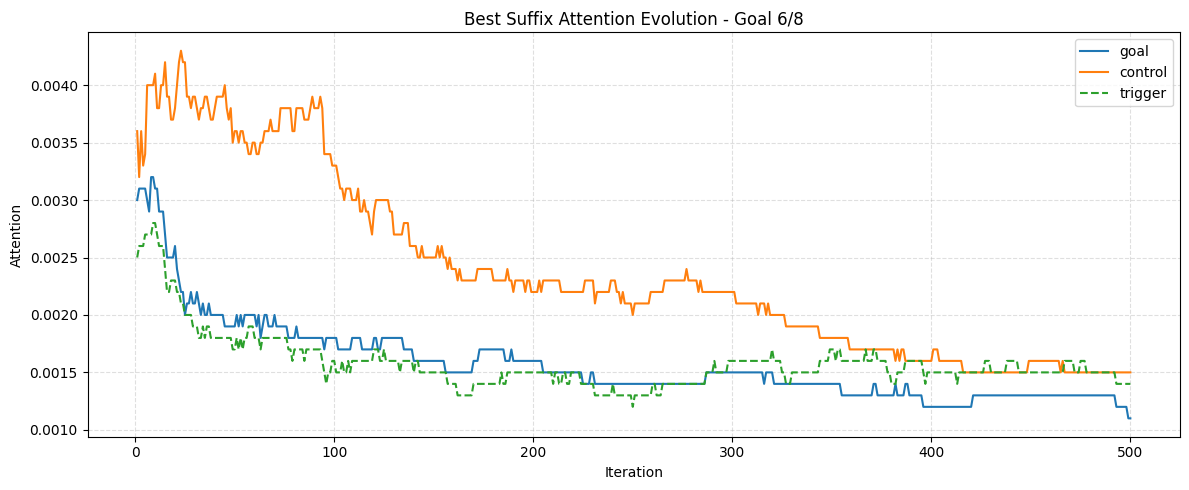

Goal 6/8: 共 500 次最优后缀记录


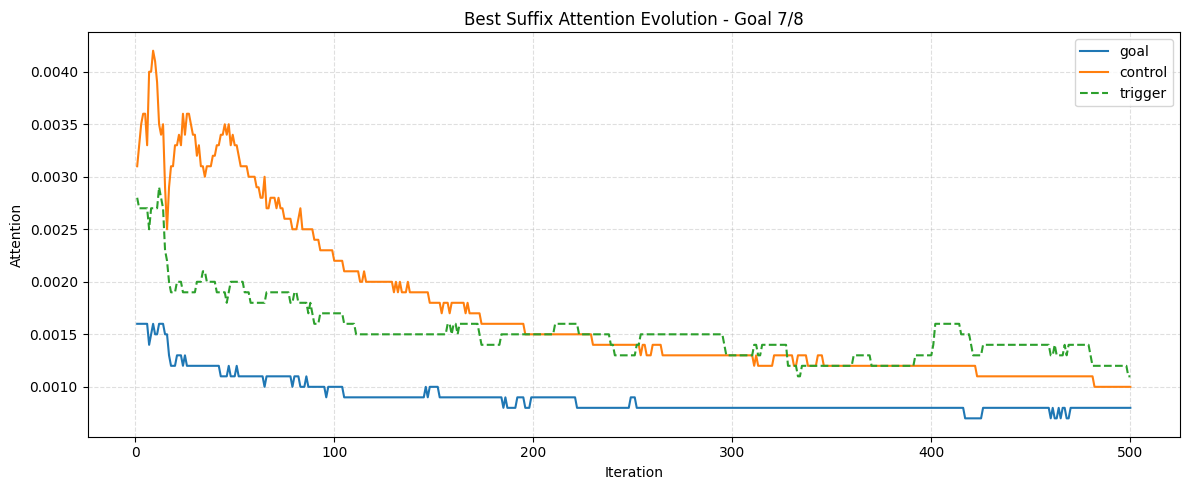

Goal 7/8: 共 500 次最优后缀记录


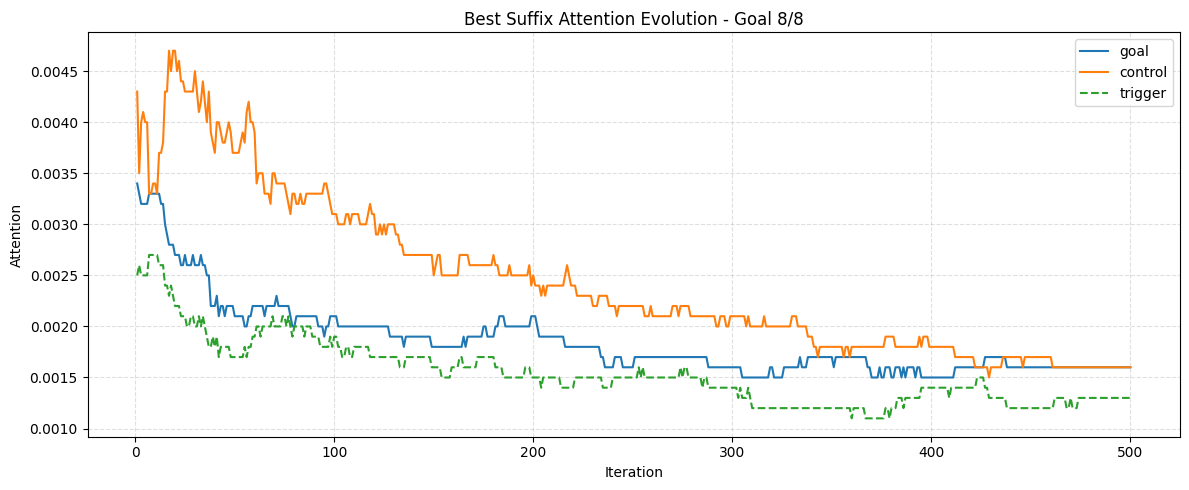

Goal 8/8: 共 500 次最优后缀记录
已导出最优后缀 attention: /home/dataset/2024_zox_llm/code/AttnGCG/experiments/bash_scripts/out_gemma_7b_attngcg_direct/10_15_iwatched_8_6_128_best_attn.csv


,goal,iter,goal_attn,sys_role_attn,control_attn,trigger_attn
0,Goal 1/8,1,0.0023,0.1582,0.0040,0.0024
1,Goal 1/8,2,0.0023,0.1602,0.0034,0.0024
2,Goal 1/8,3,0.0023,0.1621,0.0033,0.0024
3,Goal 1/8,4,0.0022,0.1602,0.0037,0.0024
4,Goal 1/8,5,0.0022,0.1582,0.0036,0.0023


In [6]:
import re
import matplotlib.pyplot as plt
import pandas as pd


BEST_ATTN_PATTERN = re.compile(
    r"\[BEST Attn\]\s+"
    r"goal=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"sys_role=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"control=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\|\s*"
    r"trigger=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
)
GOAL_PATTERN = re.compile(r"Goal\s+(\d+)/(\d+)")


def parse_best_attention_only(log_file_path: str) -> pd.DataFrame:
    with open(log_file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    current_goal = "Goal 1/1"
    rows = []
    iter_idx_by_goal = {}

    for line in lines:
        g = GOAL_PATTERN.search(line)
        if g:
            current_goal = f"Goal {g.group(1)}/{g.group(2)}"
            iter_idx_by_goal.setdefault(current_goal, 0)

        m = BEST_ATTN_PATTERN.search(line)
        if not m:
            continue

        iter_idx_by_goal.setdefault(current_goal, 0)
        iter_idx_by_goal[current_goal] += 1

        rows.append(
            {
                "goal": current_goal,
                "iter": iter_idx_by_goal[current_goal],
                "goal_attn": float(m.group(1)),
                "sys_role_attn": float(m.group(2)),
                "control_attn": float(m.group(3)),
                "trigger_attn": float(m.group(4)),
            }
        )

    return pd.DataFrame(rows)


def plot_best_attention_only(df: pd.DataFrame, rolling_window: int = 1):
    if df.empty:
        print("未找到 [BEST Attn] 日志。请使用修复后的代码重新跑实验。")
        return

    for goal_name, gdf in df.groupby("goal"):
        plot_df = gdf.sort_values("iter").copy()
        if rolling_window > 1:
            for col in ["goal_attn", "sys_role_attn", "control_attn", "trigger_attn"]:
                plot_df[col] = plot_df[col].rolling(rolling_window, min_periods=1).mean()

        plt.figure(figsize=(12, 5))
        plt.plot(plot_df["iter"], plot_df["goal_attn"], label="goal")
        # plt.plot(plot_df["iter"], plot_df["sys_role_attn"], label="sys_role", alpha=0.7)
        plt.plot(plot_df["iter"], plot_df["control_attn"], label="control")
        plt.plot(plot_df["iter"], plot_df["trigger_attn"], label="trigger", linestyle="--")
        plt.title(f"Best Suffix Attention Evolution - {goal_name}")
        plt.xlabel("Iteration")
        plt.ylabel("Attention")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"{goal_name}: 共 {len(plot_df)} 次最优后缀记录")


best_log_path = "/home/dataset/2024_zox_llm/code/AttnGCG/experiments/bash_scripts/out_gemma_7b_attngcg_direct/10_15_iwatched_8_6_128.out"

best_df = parse_best_attention_only(best_log_path)
plot_best_attention_only(best_df, rolling_window=1)

if not best_df.empty:
    best_csv_path = best_log_path.replace(".out", "_best_attn.csv")
    best_df.to_csv(best_csv_path, index=False)
    print(f"已导出最优后缀 attention: {best_csv_path}")
    display(best_df.head())
